<a href="https://colab.research.google.com/github/nora-mohamed25/data-analysis-portfolio/blob/main/Project_05_Internet_Usage_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
استوردنا مكتبة  pandas  باسم  pd،
ومكتبة  train_test_split من  مكتبة sklearn.model_selection  ، ومكتبة  LinearRegression
من  مكتبة sklearn.linear_model  ، ومكتبة  mean_squared_error
من  مكتبة sklearn.metrics

In [ ]:
import pandas as pd
df = pd.read_csv("/content/internet_usage.csv")

In [ ]:
df.head()

,number_of_people,number_of_devices,daily_usage_hours,video_streaming,online_gaming,work_from_home,monthly_internet_usage
0,4,2,7.0,0,0,1,57.9
1,5,6,4.0,1,1,0,112.3
2,3,6,2.4,0,0,0,53.5
3,5,3,9.8,0,0,1,63.7
4,5,7,8.6,0,0,1,113.5


In [ ]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   number_of_people        200 non-null    int64  
 1   number_of_devices       200 non-null    int64  
 2   daily_usage_hours       200 non-null    float64
 3   video_streaming         200 non-null    int64  
 4   online_gaming           200 non-null    int64  
 5   work_from_home          200 non-null    int64  
 6   monthly_internet_usage  200 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 11.1 KB


In [ ]:
df.isnull().sum()

,0
number_of_people,0
number_of_devices,0
daily_usage_hours,0
video_streaming,0
online_gaming,0
work_from_home,0
monthly_internet_usage,0


In [ ]:
binary_columns = ['video_streaming', 'online_gaming', 'work_from_home']

summary = df[binary_columns].sum()
summary

,0
video_streaming,99
online_gaming,98
work_from_home,93


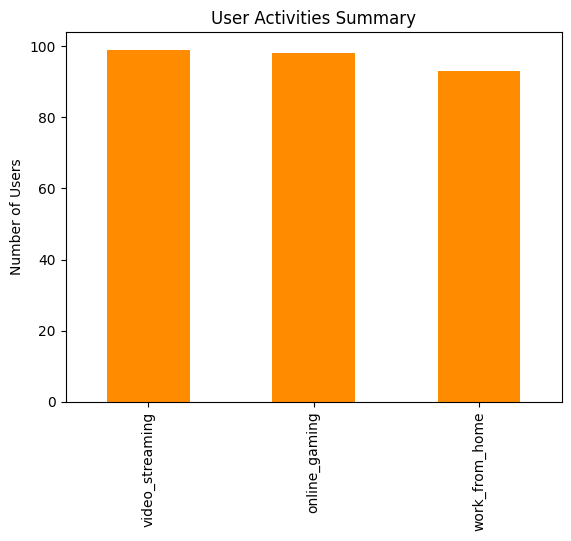

In [ ]:
summary.plot(kind='bar', color='darkorange')

plt.title('User Activities Summary')
plt.ylabel('Number of Users')
plt.show()

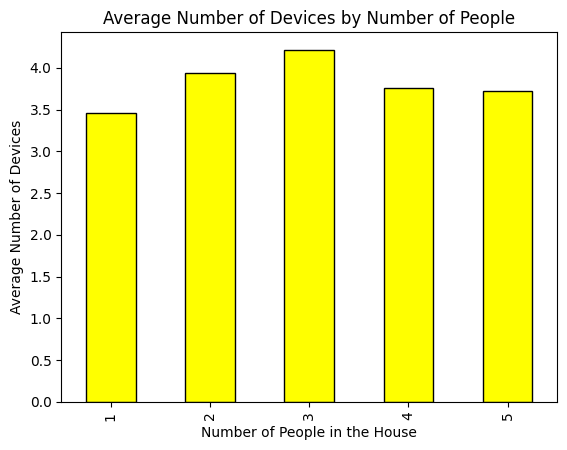

In [ ]:
people_devices_table = df.groupby('number_of_people')['number_of_devices'].mean()

people_devices_table.plot(
    kind='bar',
    color='yellow',
    edgecolor='black'
)

plt.title('Average Number of Devices by Number of People')
plt.xlabel('Number of People in the House')
plt.ylabel('Average Number of Devices')
plt.show()

In [ ]:
devices_by_people = df.groupby('number_of_people')['number_of_devices'].sum()
devices_by_people

,number_of_devices
number_of_people,
1,149
2,138
3,156
4,184
5,134


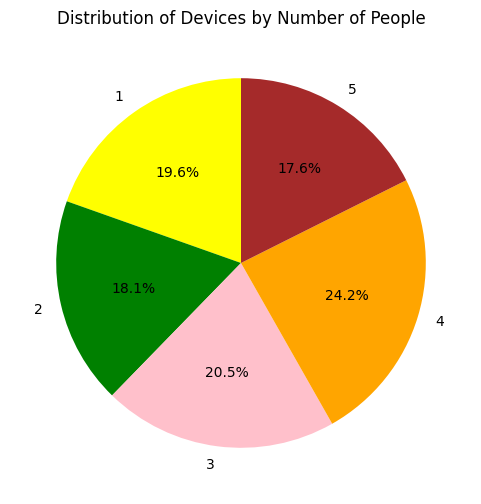

In [ ]:
plt.figure(figsize=(6,6))

devices_by_people.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['yellow','green','pink','Orange','brown']
)

plt.title('Distribution of Devices by Number of People')
plt.ylabel('')
plt.show()

In [ ]:
x = df.drop("monthly_internet_usage", axis=1)
y = df["monthly_internet_usage"]

In [ ]:

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [ ]:

linear = LinearRegression()
linear.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = linear.predict(x_test)
y_pred

array([ 95.60526712,  50.34701283,  61.62389021, 126.72713876,
        63.53536546,  62.52540842,  69.86494874, 102.71074278,
       107.03426712,  38.13691698,  46.07681163, 110.24213576,
        45.02204614,  79.26060982,  84.67735543,  81.68591173,
        73.02304214,  77.17925483,  69.81075322,  72.17308791,
        67.56471812, 111.38305526,  69.15450383, 150.25776742,
        57.64223577,  91.48332279,  51.8625997 , 100.83888016,
        17.89268306,  75.69678328,  97.27909642,  82.16731841,
        64.52852178,  92.44252478, 125.69258108,  63.03813787,
        88.15791774, 103.72474262,  79.60198482, 112.29069328])

In [ ]:
df_compare = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
df_compare

,Actual,Predicted
18,88.5,95.605267
170,55.6,50.347013
107,60.0,61.623890
98,113.6,126.727139
177,63.0,63.535365
182,51.5,62.525408
5,52.8,69.864949
146,111.3,102.710743
12,99.3,107.034267
152,22.1,38.136917


In [ ]:
mse = mean_squared_error(y_test, y_pred)
mse

96.94008713079054